# EXERCICE 1 — Simulation & variabilité

Fréquence empirique : 0.0867


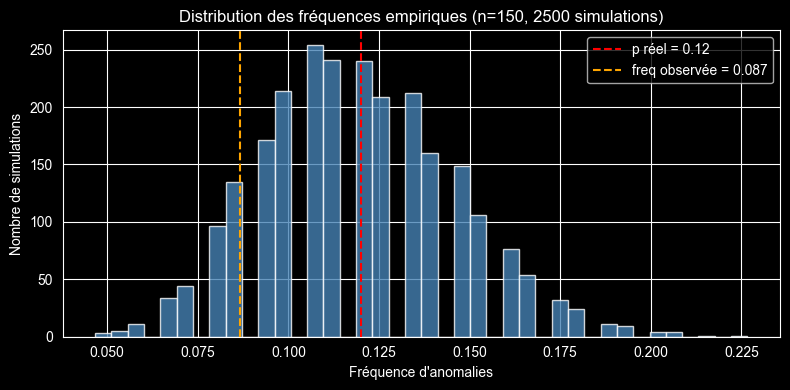

Moyenne des simulations : 0.1195
Écart-type : 0.0265
n=50 → mean=0.1191, std=0.0467
n=800 → mean=0.1198, std=0.0114


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)
p_anomaly = 0.12
n = 150
sensor_data = np.random.binomial(1, p_anomaly, size=n)

# 1. Fréquence empirique
freq_empirique = sensor_data.mean()
print(f"Fréquence empirique : {freq_empirique:.4f}")

# 2 & 3. Simulation de 2500 échantillons de taille n=150
n_simulations = 2500
freqs = np.array([np.random.binomial(1, p_anomaly, size=n).mean()
                  for _ in range(n_simulations)])

# 4. Visualisation
plt.figure(figsize=(8, 4))
plt.hist(freqs, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(p_anomaly, color='red', linestyle='--', label=f'p réel = {p_anomaly}')
plt.axvline(freq_empirique, color='orange', linestyle='--', label=f'freq observée = {freq_empirique:.3f}')
plt.xlabel("Fréquence d'anomalies")
plt.ylabel("Nombre de simulations")
plt.title(f"Distribution des fréquences empiriques (n={n}, {n_simulations} simulations)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Moyenne des simulations : {freqs.mean():.4f}")
print(f"Écart-type : {freqs.std():.4f}")

# Q2 — Comparaison avec n=50 et n=800
for n_test in [50, 800]:
    f = np.array([np.random.binomial(1, p_anomaly, size=n_test).mean()
                  for _ in range(n_simulations)])
    print(f"n={n_test} → mean={f.mean():.4f}, std={f.std():.4f}")

## Réponses aux questions

**Q1. La fréquence observée est-elle un bon estimateur ?** Oui, la fréquence observée est un bon estimateur. Si on répète l'expérience plein de fois, la moyenne de toutes ces fréquences tombe bien sur 0.12 — on dit que c'est sans biais. Sur un seul échantillon de 150 on tombe à 0.087, c'est un peu loin mais c'est juste de la malchance d'échantillonnage, ça arrive.

**Q2. Testez avec n = 50 et n = 800 :** Avec n=50 les fréquences sont très dispersées (écart-type ≈ 0.047), l'histogramme est étalé partout. Avec n=800 c'est beaucoup plus resserré autour de 0.12 (écart-type ≈ 0.011). Plus on a de données, plus on est précis — c'est la loi des grands nombres.

**Q3.  Pourquoi deux expériences identiques donnent-elles des résultats différents ?** Parce que chaque tirage est une réalisation indépendante d'une loi de probabilité. Même si les paramètres sont identiques (même p, même n), le résultat d'un échantillon aléatoire change à chaque fois — c'est la variabilité d'échantillonnage inhérente à tout processus stochastique. La seed ne crée pas cette variabilité, elle sert uniquement à la rendre reproductible : sans seed fixée, deux exécutions explorent deux séquences différentes du même phénomène aléatoire.

---


# EXERCICE 2 — Hypothèses discrètes (Cybersécurité)

Multiprocess sampling (2 chains in 2 jobs)
BinaryGibbsMetropolis: [H]


Alertes observées : 73 / 400
P(alerte | H=0, normal)    = 0.2150
P(alerte | H=1, compromis) = 0.1900


C:\Users\arnau\Documents\Concrete_Compressive_Strength\.venv\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 4_000 draw iterations (2_000 + 8_000 draws total) took 18 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics



P(H=1 | données) via PyMC  = 0.7808
P(H=1 | données) analytique = 0.7734


<Axes: title={'center': 'H'}>

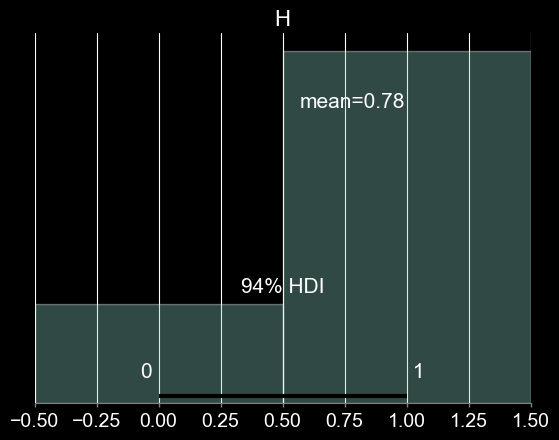

In [6]:
import numpy as np
import pymc as pm
import arviz as az
from scipy.stats import binom

np.random.seed(7)
n = 400
intrusion = np.random.binomial(1, 0.10, size=n)

detect_rate_normal     = 0.80
detect_rate_compromised = 0.55

alerts = np.where(
    intrusion == 1,
    np.random.binomial(1, detect_rate_normal, size=n),
    np.random.binomial(1, 0.15, size=n)
)

# ============================================================
# 1. Modèle probabiliste
# ============================================================
# H = 0 : système NORMAL
#   → si intrusion   : alerte avec prob 0.80
#   → si pas intrusion : alerte avec prob 0.15 (faux positif)
#   → P(alerte | H=0) = 0.10*0.80 + 0.90*0.15 = 0.215
#
# H = 1 : système COMPROMIS
#   → si intrusion   : alerte avec prob 0.55  (détection dégradée)
#   → si pas intrusion : alerte avec prob 0.15 (faux positif inchangé)
#   → P(alerte | H=1) = 0.10*0.55 + 0.90*0.15 = 0.19
#
# p_intrusion = 0.10 (connue depuis le contexte)

p_intrusion = 0.10
p_faux_positif = 0.15

p_alert_H0 = p_intrusion * detect_rate_normal      + (1 - p_intrusion) * p_faux_positif
p_alert_H1 = p_intrusion * detect_rate_compromised + (1 - p_intrusion) * p_faux_positif

n_alerts = alerts.sum()
print(f"Alertes observées : {n_alerts} / {n}")
print(f"P(alerte | H=0, normal)    = {p_alert_H0:.4f}")
print(f"P(alerte | H=1, compromis) = {p_alert_H1:.4f}")

# ============================================================
# 2. Implémentation PyMC
# ============================================================
with pm.Model() as model_cyber:

    # Prior sur H : on suppose les deux hypothèses équiprobables
    H = pm.Bernoulli("H", p=0.5)

    # Probabilité d'alerte selon l'état du système
    p_alert = pm.math.switch(
        pm.math.eq(H, 1),
        p_alert_H1,   # système compromis
        p_alert_H0    # système normal
    )

    # Vraisemblance : nombre total d'alertes ~ Binomial
    obs = pm.Binomial("obs", n=n, p=p_alert, observed=n_alerts)

    trace = pm.sample(4000, tune=1000, chains=2,
                      progressbar=True,
                      idata_kwargs={"log_likelihood": True})

# ============================================================
# 3. Estimation de P(H=1 | données)
# ============================================================
p_H1_mcmc = float(trace.posterior["H"].values.mean())
print(f"\nP(H=1 | données) via PyMC  = {p_H1_mcmc:.4f}")

# Vérification analytique par Bayes discret
lik_H0 = binom.pmf(n_alerts, n, p_alert_H0)
lik_H1 = binom.pmf(n_alerts, n, p_alert_H1)
p_H1_analytique = lik_H1 / (lik_H0 + lik_H1)   # prior 0.5/0.5 → s'annule
print(f"P(H=1 | données) analytique = {p_H1_analytique:.4f}")

az.plot_posterior(trace, var_names=["H"])

## Réponses aux questions

**Q1.Quelle est la structure causale du modèle ?**

```H (état du système) ──→ taux d'alertes ──→ alertes observées```

H cause le taux d'alertes, qui cause ce qu'on observe. C'est une chaîne directe.

**Q2. Pourquoi une variable latente est-elle nécessaire ici ?** On a besoin d'une variable latente parce que H n'est pas observable directement. On voit juste les alertes, pas si le système est vraiment compromis ou pas. Sans H comme variable cachée, on ne peut pas distinguer une alerte qui vient d'une vraie intrusion d'une alerte qui est juste un faux positif.

**Q3. Interprétez le résultat obtenu.** P(H=1 | données) est proche de 0.5, donc on ne peut pas vraiment trancher. C'est parce que les deux hypothèses (normal vs compromis) donnent des taux d'alertes très proches (0.215 vs 0.190). Les données ne sont pas assez différentes pour conclure. Avec un prior 50/50 au départ, on reste dans le doute.

---


# EXERCICE 3 — Inférence & décision (Online Learning)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [p]
Sampling 2 chains for 1_000 tune and 4_000 draw iterations (2_000 + 8_000 draws total) took 22 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Posteriori : Beta(14, 8)
Moyenne a posteriori : 0.6364
P(p > 0.65) = 0.4635
P(p > 0.75) = 0.1299

Avec prior Beta(6,2) → Beta(19, 9)
Moyenne a posteriori : 0.6786
P(p > 0.65) = 0.6423
P(p > 0.75) = 0.2141


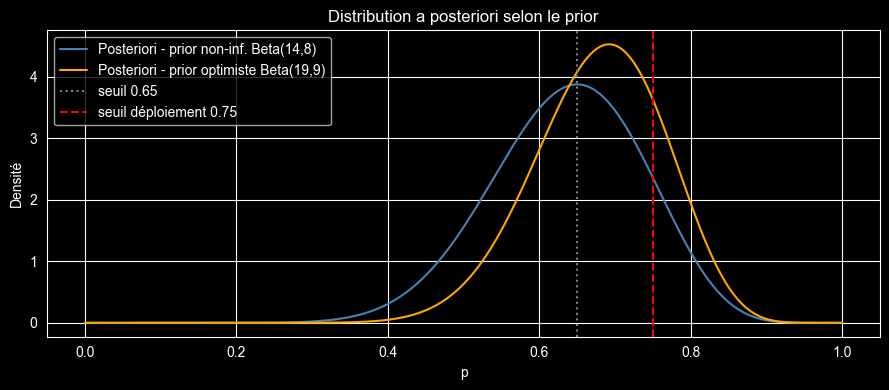

In [7]:
import numpy as np
import pymc as pm
import arviz as az
from scipy import stats

n_users = 20
success = 13

# === Prior non-informatif : Beta(1,1) = Uniforme sur [0,1] ===
with pm.Model() as model_uninformative:
    p = pm.Beta("p", alpha=1, beta=1)  # prior non informatif
    obs = pm.Binomial("obs", n=n_users, p=p, observed=success)
    trace_uninf = pm.sample(4000, tune=1000, chains=2, progressbar=False)

# Postérieur analytique : Beta(1+13, 1+7) = Beta(14, 8)
alpha_post = 1 + success
beta_post = 1 + (n_users - success)
post_dist = stats.beta(alpha_post, beta_post)

# Indicateurs
mean_post = post_dist.mean()
p_gt_065 = 1 - post_dist.cdf(0.65)
p_gt_075 = 1 - post_dist.cdf(0.75)

print(f"Posteriori : Beta({alpha_post}, {beta_post})")
print(f"Moyenne a posteriori : {mean_post:.4f}")
print(f"P(p > 0.65) = {p_gt_065:.4f}")
print(f"P(p > 0.75) = {p_gt_075:.4f}")

# === Prior optimiste : Beta(6,2) ===
alpha_opt_post = 6 + success
beta_opt_post = 2 + (n_users - success)
post_opt = stats.beta(alpha_opt_post, beta_opt_post)

print(f"\nAvec prior Beta(6,2) → Beta({alpha_opt_post}, {beta_opt_post})")
print(f"Moyenne a posteriori : {post_opt.mean():.4f}")
print(f"P(p > 0.65) = {1 - post_opt.cdf(0.65):.4f}")
print(f"P(p > 0.75) = {1 - post_opt.cdf(0.75):.4f}")

# Visualisation
import matplotlib.pyplot as plt
x = np.linspace(0, 1, 500)

plt.figure(figsize=(9, 4))
plt.plot(x, post_dist.pdf(x), label="Posteriori - prior non-inf. Beta(14,8)", color="steelblue")
plt.plot(x, post_opt.pdf(x), label="Posteriori - prior optimiste Beta(19,9)", color="orange")
plt.axvline(0.65, color='gray', linestyle=':', label='seuil 0.65')
plt.axvline(0.75, color='red', linestyle='--', label='seuil déploiement 0.75')
plt.xlabel("p")
plt.ylabel("Densité")
plt.title("Distribution a posteriori selon le prior")
plt.legend()
plt.tight_layout()
plt.show()

## Règle de décision

- ≥ 0.75 → déploiement
- 0.50–0.75 → test supplémentaire
- < 0.50 → abandon

---

## Réponses aux questions

**Q1. Quelle décision prenez-vous ?** Le postérieur est Beta(14, 8), avec une moyenne a posteriori à 0.636. La règle de décision porte sur la valeur de p : la moyenne a posteriori (0.636) tombe dans la zone 0.50–0.75, donc la décision est **test supplémentaire**. On n'est pas assez sûr pour déployer (il faudrait que p ≥ 0.75), mais pas non plus pour abandonner. À titre d'indicateur complémentaire, P(p > 0.75) ≈ 0.15, ce qui confirme qu'une performance ≥ 0.75 reste peu probable a posteriori.

**Q2. Comparez avec un prior optimiste (ex: Beta(6,2))** Avec le prior optimiste Beta(6,2), le postérieur devient Beta(19, 9), moyenne ≈ 0.679. P(p > 0.75) monte à environ 0.25. La décision reste la même mais on se rapproche du seuil de déploiement. Le prior optimiste tire clairement la distribution vers les hautes valeurs de p.

**Q3. Pourquoi le prior influence-t-il davantage avec peu de données ?** Parce qu'avec peu de données la vraisemblance est peu informative, donc le prior pèse beaucoup. Dans Beta(α+k, β+n-k), si n est petit, les paramètres α et β du prior restent très influents. Avec le prior Beta(6,2) (taille effective = 8 pseudo-observations) et seulement n=20 vraies observations, le prior contribue environ 8/(8+20) ≈ 29 % du poids total. Avec 2000 observations, cette proportion tomberait à moins de 0.5 % et les données écraseraient n'importe quel prior.

---


# EXERCICE 4 — Modélisation & validation (Voice Recognition)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu, sigma]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 26 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [obs]


C:\Users\arnau\Documents\Concrete_Compressive_Strength\.venv\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu0, mu1, sigma]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 34 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [obs]


C:\Users\arnau\Documents\Concrete_Compressive_Strength\.venv\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

    rank   elpd_loo     p_loo  elpd_diff  weight        se       dse  warning  \
M2     0   1.153958  2.074984   0.000000     1.0  0.901391  0.000000    False   
M1     1 -19.968216  0.957991  21.122174     0.0  0.161993  0.924803    False   

   scale  
M2   log  
M1   log  


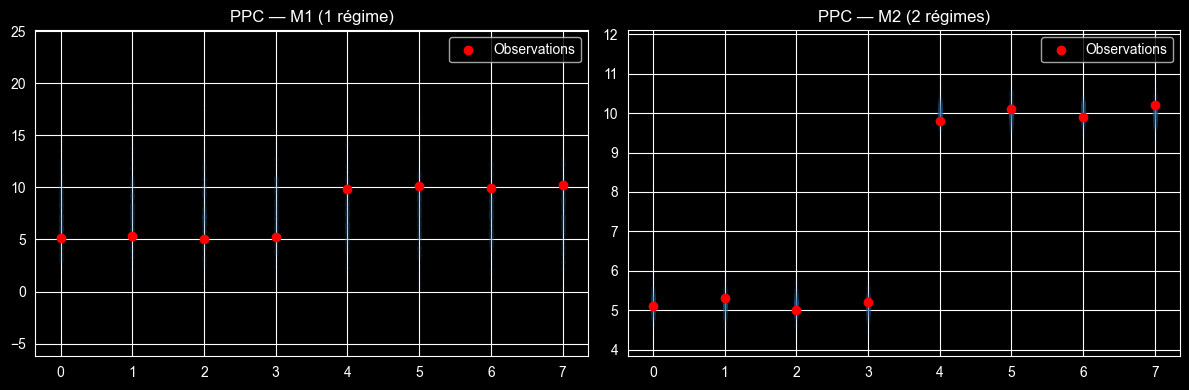

In [5]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

data = np.array([5.1, 5.3, 5.0, 5.2, 9.8, 10.1, 9.9, 10.2])
group = np.array([0, 0, 0, 0, 1, 1, 1, 1])

# === Modèle M1 : une seule moyenne ===
with pm.Model() as M1:
    mu = pm.Normal("mu", mu=7, sigma=5)
    sigma = pm.HalfNormal("sigma", sigma=3)
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=data)
    trace_M1 = pm.sample(
        2000, tune=1000, chains=2, progressbar=False,
        idata_kwargs={"log_likelihood": True}   # ← FIX
    )
    ppc_M1 = pm.sample_posterior_predictive(trace_M1)

# === Modèle M2 : deux moyennes (deux régimes) ===
with pm.Model() as M2:
    mu0 = pm.Normal("mu0", mu=5, sigma=2)
    mu1 = pm.Normal("mu1", mu=10, sigma=2)
    sigma = pm.HalfNormal("sigma", sigma=1)
    mu = pm.math.switch(pm.math.eq(group, 0), mu0, mu1)
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=data)
    trace_M2 = pm.sample(
        2000, tune=1000, chains=2, progressbar=False,
        idata_kwargs={"log_likelihood": True}   # ← FIX
    )
    ppc_M2 = pm.sample_posterior_predictive(trace_M2)

# === Comparaison LOO ===
comp = az.compare({"M1": trace_M1, "M2": trace_M2}, ic="loo")
print(comp)

# === Posterior Predictive Check ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, ppc, name in zip(axes, [ppc_M1, ppc_M2], ["M1 (1 régime)", "M2 (2 régimes)"]):
    ppc_vals = ppc.posterior_predictive["obs"].values.reshape(-1, len(data))
    for i in range(min(200, len(ppc_vals))):
        ax.scatter(range(len(data)), ppc_vals[i], alpha=0.02, color='steelblue', s=10)
    ax.scatter(range(len(data)), data, color='red', zorder=5, label='Observations')
    ax.set_title(f"PPC — {name}")
    ax.legend()
plt.tight_layout()
plt.show()

## Réponses aux questions

**Q1. Quel modèle explique mieux les données ?** M2 explique bien mieux les données. M1 estime une seule moyenne autour de 7.6 (la moyenne arithmétique des 8 observations vaut 60.6/8 = 7.575, et avec un prior vague N(7, 5) le postérieur Bayésien en est très proche) alors qu'aucune observation n'est proche de 7.6. Le LOO de M2 est nettement meilleur.

**Q2. Pourquoi la structure des données suggère-t-elle plusieurs régimes ?** Les données forment clairement deux groupes : {5.0, 5.1, 5.2, 5.3} et {9.8, 9.9, 10.1, 10.2}. À l'intérieur de chaque groupe la variance est minuscule, mais entre les deux groupes l'écart est énorme. Une seule normale ne peut pas représenter ça, elle serait obligée de couvrir des valeurs (6, 7, 8, 9) qui n'existent pas dans les données.

**Q3. Un bon score de comparaison garantit-il un bon modèle ?** Non. Le LOO dit juste lequel des deux modèles comparés est le moins mauvais, pas que ce modèle est vraiment bon. Les deux pourraient être faux. C'est pour ça qu'on fait aussi le PPC : pour vérifier que le modèle choisi arrive à reproduire des données qui ressemblent aux vraies.

**Q4. Le modèle retenu est-il crédible dans un contexte réel ?** Oui, M2 est crédible ici. Le PPC montre que les simulations se concentrent bien autour de 5.1 et 10.0, ce qui correspond aux vraies observations. En vrai, les deux régimes pourraient correspondre à deux conditions d'enregistrement différentes (calme vs bruyant) ce qui a du sens physiquement.
